In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
# Đảm bảo bạn đã đặt các file .py cùng thư mục với notebook
from solvers import solve_using_gauss, solve_using_svd, solve_gauss_seidel, compute_relative_error

sizes = [50, 100, 200, 500, 1000]
# Lưu trữ kết quả cho 3 phương pháp
results = {
    "Gauss": {"times": [], "errors": []},
    "SVD": {"times": [], "errors": []},
    "Gauss-Seidel": {"times": [], "errors": []}
}

In [2]:
for n in sizes:
    print(f"Đang thực nghiệm n = {n}...")
    # Sinh ma trận A (SPD) và vector b
    A_raw = np.random.rand(n, n)
    A = (np.dot(A_raw, A_raw.T) + n * np.eye(n)).tolist()
    b = np.random.rand(n).tolist()
    
    # 1. Thực nghiệm cho Gauss
    t_gauss = []
    for _ in range(5):
        start = time.perf_counter()
        x_g = solve_using_gauss(A, b)
        t_gauss.append(time.perf_counter() - start)
    results["Gauss"]["times"].append(np.mean(t_gauss))
    results["Gauss"]["errors"].append(compute_relative_error(A, x_g, b))

    # 2. Thực nghiệm cho SVD
    t_svd = []
    for _ in range(5):
        start = time.perf_counter()
        x_s = solve_using_svd(A, b)
        t_svd.append(time.perf_counter() - start)
    results["SVD"]["times"].append(np.mean(t_svd))
    results["SVD"]["errors"].append(compute_relative_error(A, x_s, b))

    # 3. Thực nghiệm cho Gauss-Seidel
    t_gs = []
    for _ in range(5):
        start = time.perf_counter()
        x_gs, _, _ = solve_gauss_seidel(A, b)
        t_gs.append(time.perf_counter() - start)
    results["Gauss-Seidel"]["times"].append(np.mean(t_gs))
    results["Gauss-Seidel"]["errors"].append(compute_relative_error(A, x_gs, b))

Đang thực nghiệm n = 50...
Đang thực nghiệm n = 100...
Đang thực nghiệm n = 200...
Đang thực nghiệm n = 500...
Đang thực nghiệm n = 1000...


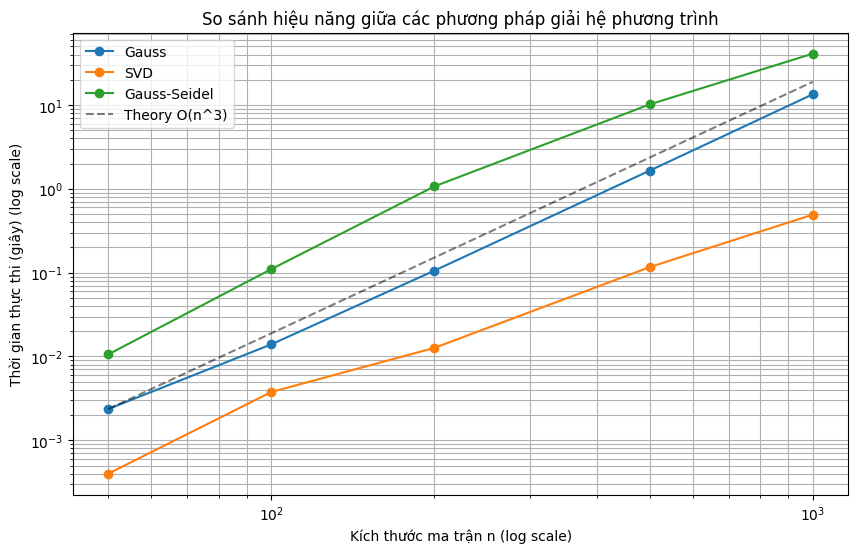

In [3]:
plt.figure(figsize=(10, 6))
for method in results:
    plt.loglog(sizes, results[method]["times"], '-o', label=method)

# Vẽ đường O(n^3) lý thuyết để đối chiếu
n_theory = np.array(sizes)
t_theory = (n_theory**3) * (results["Gauss"]["times"][0] / sizes[0]**3)
plt.loglog(sizes, t_theory, '--k', alpha=0.5, label='Theory O(n^3)')

plt.xlabel('Kích thước ma trận n (log scale)')
plt.ylabel('Thời gian thực thi (giây) (log scale)')
plt.title('So sánh hiệu năng giữa các phương pháp giải hệ phương trình')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()